# Exploratory Data Analysis (EDA)


In [2]:
%pip install pandas numpy matplotlib seaborn scipy statsmodels gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style='whitegrid')



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Load Data


In [6]:
import gdown
df = pd.read_csv(gdown.download(id='1a-MNVGzc5DV-MTDmkWOCP5qhVTaaZMnu', quiet=False))

# Convert order_date to datetime if not already
df['order_date'] = pd.to_datetime(df['order_date'])
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'https://drive.google.com/uc?export=download&id=1a-MNVGzc5DV-MTDmkWOCP5qhVTaaZMnu'

## 2. Basic Dataset Information


In [5]:
print(f'Dataset Shape: {df.shape}')
df.info()


Dataset Shape: (1000000, 29)
<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 29 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   order_id        1000000 non-null  str           
 1   order_date      1000000 non-null  datetime64[us]
 2   product_id      1000000 non-null  str           
 3   store_id        1000000 non-null  str           
 4   customer_id     1000000 non-null  str           
 5   quantity        1000000 non-null  int64         
 6   unit_price      1000000 non-null  float64       
 7   discount        1000000 non-null  float64       
 8   revenue         1000000 non-null  float64       
 9   cost            1000000 non-null  float64       
 10  profit          1000000 non-null  float64       
 11  age             1000000 non-null  int64         
 12  gender          1000000 non-null  str           
 13  loyalty_member  1000000 non-null  int64         
 14  j

In [6]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
order_date,1000000,2023-12-31 19:03:34.991999,2023-01-01 00:00:00,2023-07-02 00:00:00,2024-01-01 00:00:00,2024-07-02 00:00:00,2024-12-31 00:00:00,NaN
quantity,1000000.0,2.999589,1.0,2.0,3.0,4.0,5.0,1.413621
unit_price,1000000.0,9.002449,3.0,6.0,9.01,12.0,15.0,3.462902
discount,1000000.0,0.056248,0.0,0.0,0.0,0.15,0.2,0.076809
revenue,1000000.0,25.486129,2.4,12.16,21.92,35.88,75.0,16.367864
cost,1000000.0,15.291554,1.2,7.24,13.03,21.41,52.43,9.972706
profit,1000000.0,10.194565,0.73,4.78,8.6,14.17,37.43,6.77876
age,1000000.0,44.044222,18.0,31.0,44.0,57.0,70.0,15.330664
loyalty_member,1000000.0,0.501898,0.0,0.0,1.0,1.0,1.0,0.499997
cocoa_percent,1000000.0,68.47297,0.0,50.0,70.0,80.0,90.0,16.038277


## 3. Univariate Analysis
### Numerical Variables


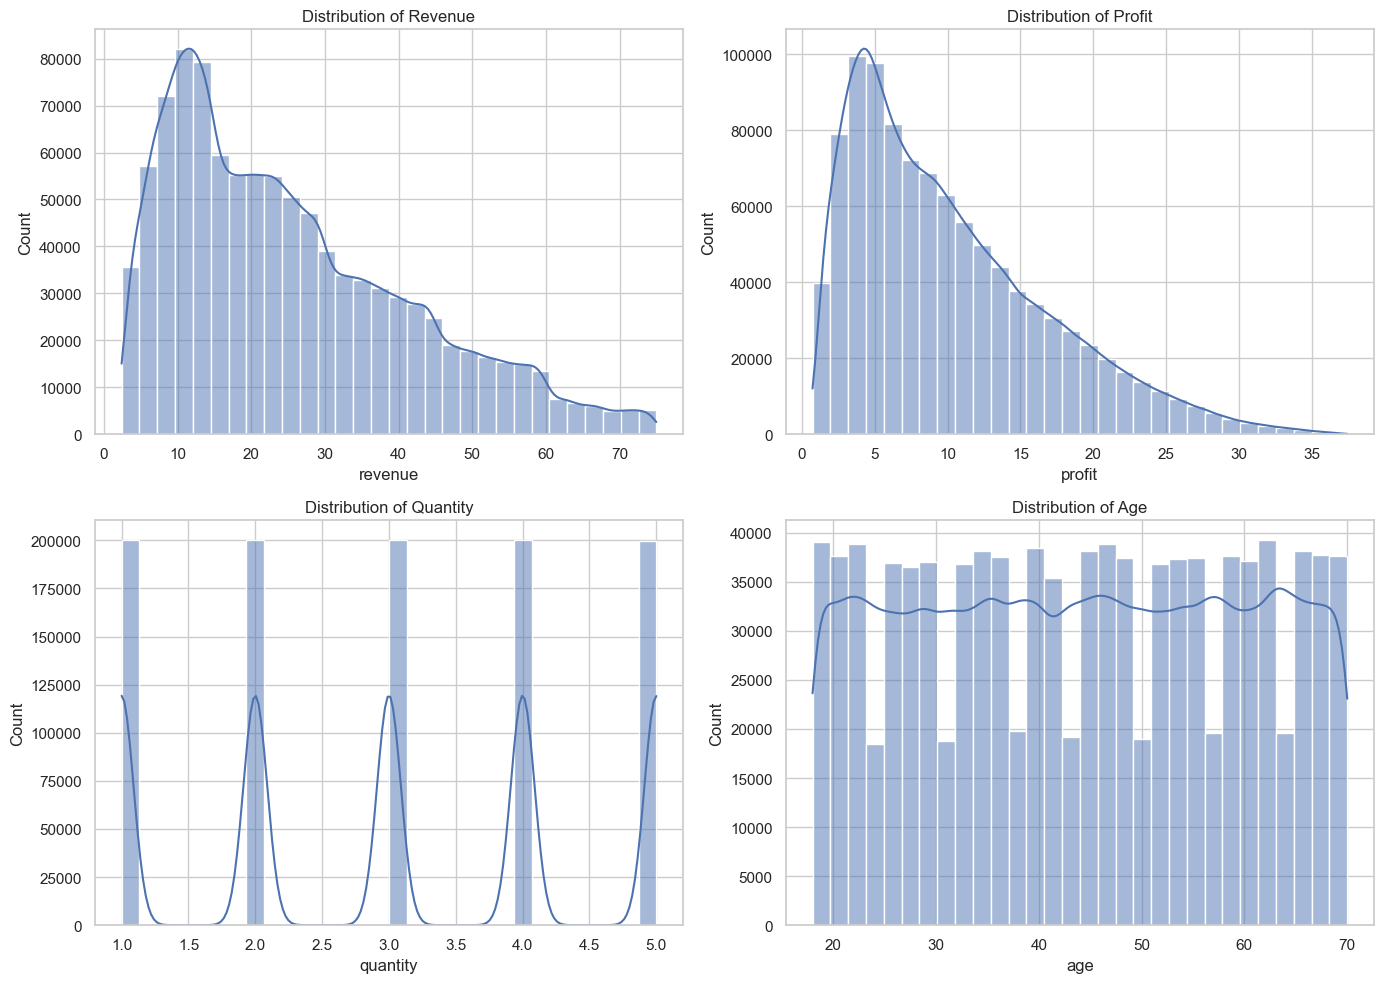

In [7]:
numerical_cols = ['revenue', 'profit', 'quantity', 'age']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Distribution of {col.capitalize()}')
plt.tight_layout()
plt.show()


### Categorical Variables


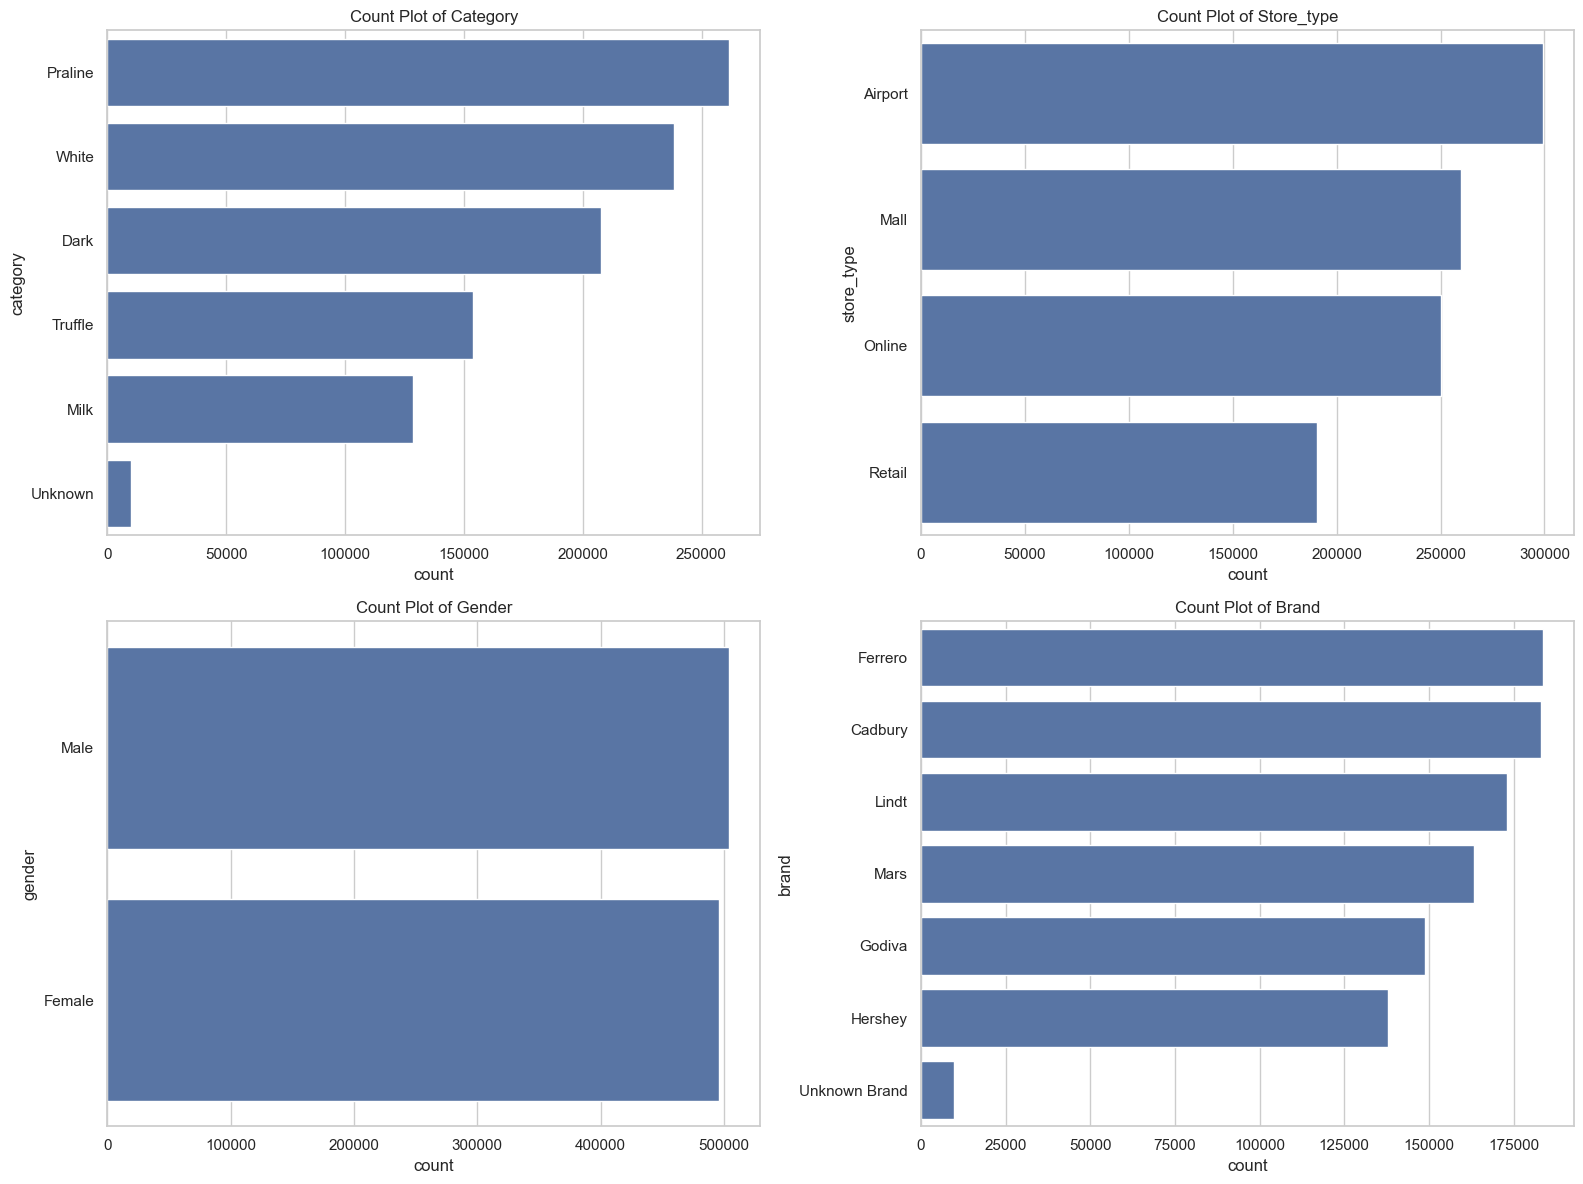

In [8]:
categorical_cols = ['category', 'store_type', 'gender', 'brand']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, y=col, ax=axes[i//2, i%2], order=df[col].value_counts().index)
    axes[i//2, i%2].set_title(f'Count Plot of {col.capitalize()}')
plt.tight_layout()
plt.show()


## 4. Bivariate Analysis
### Revenue and Profit Trends Over Time


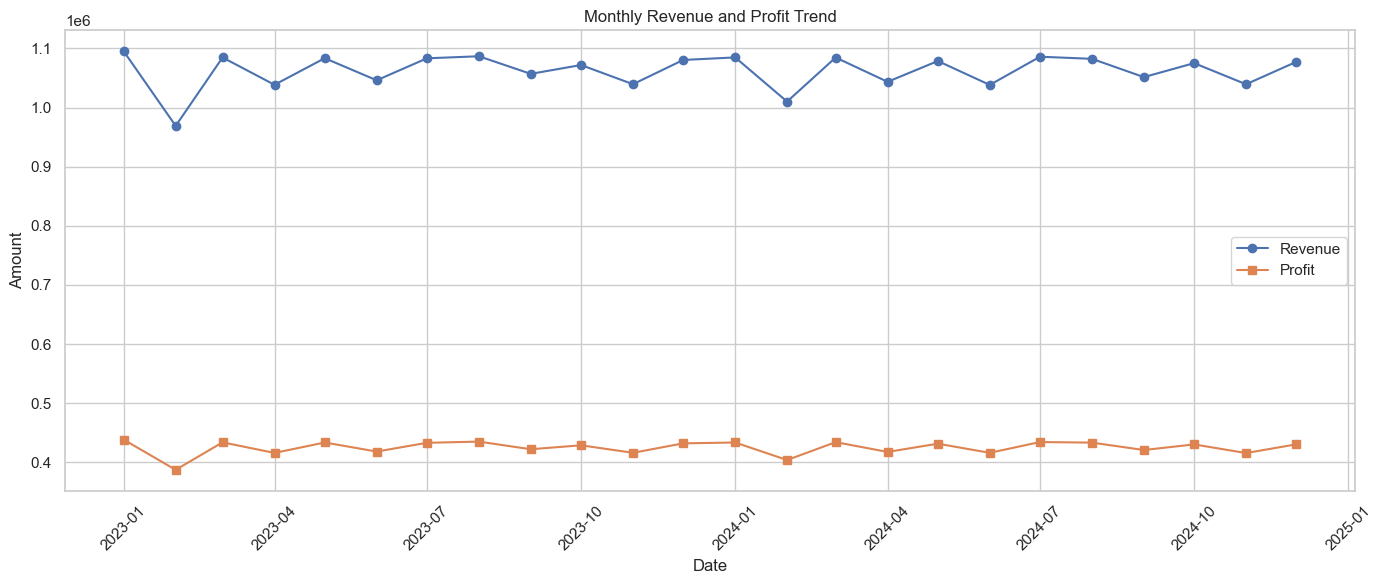

In [9]:
monthly_data = df.groupby(['year', 'month'])[['revenue', 'profit']].sum().reset_index()
monthly_data['date'] = pd.to_datetime(monthly_data['year'].astype(str) + '-' + monthly_data['month'].astype(str) + '-01')
monthly_data = monthly_data.sort_values('date')

plt.figure(figsize=(14, 6))
plt.plot(monthly_data['date'], monthly_data['revenue'], label='Revenue', marker='o')
plt.plot(monthly_data['date'], monthly_data['profit'], label='Profit', marker='s')
plt.title('Monthly Revenue and Profit Trend')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Profitability by Product Category


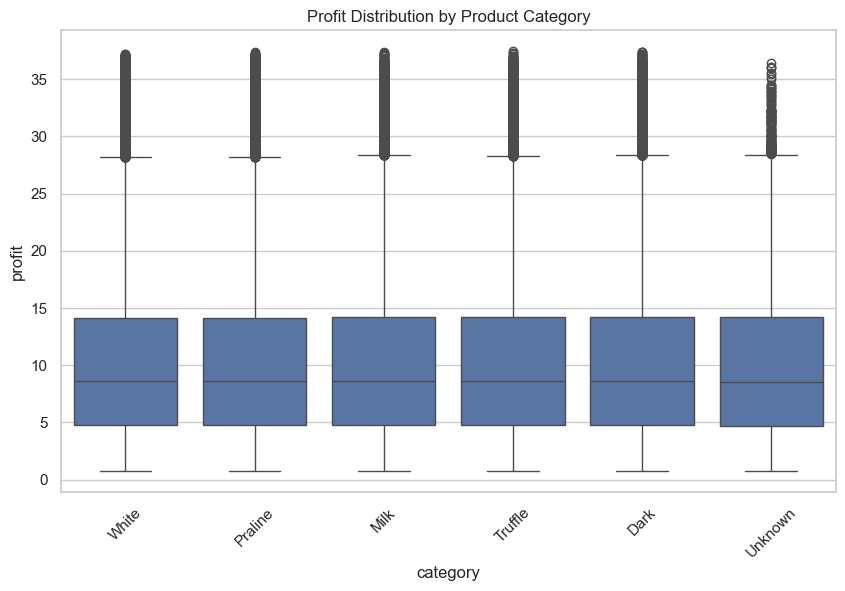

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='profit')
plt.title('Profit Distribution by Product Category')
plt.xticks(rotation=45)
plt.show()


### Revenue by Store Country


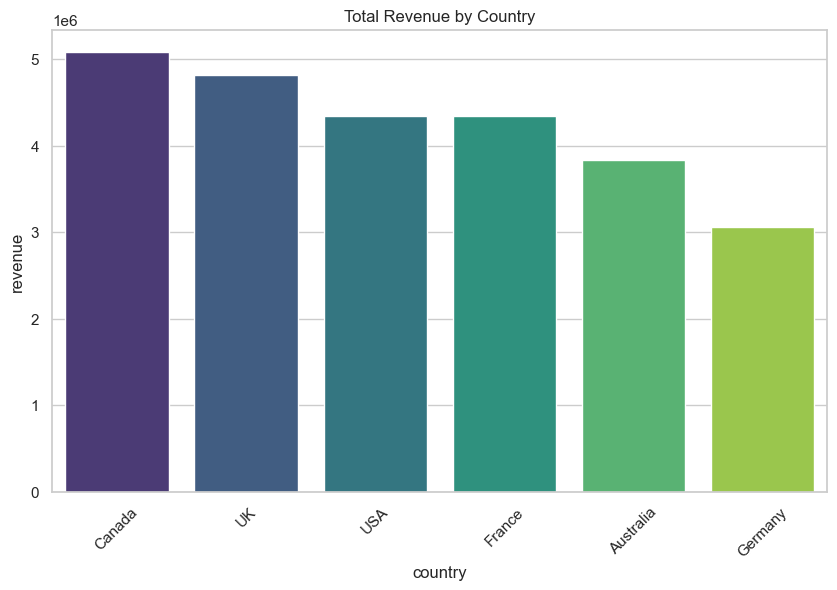

In [11]:
country_revenue = df.groupby('country')['revenue'].sum().reset_index().sort_values('revenue', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=country_revenue, x='country', y='revenue', palette='viridis')
plt.title('Total Revenue by Country')
plt.xticks(rotation=45)
plt.show()


## 5. Correlation Heatmap


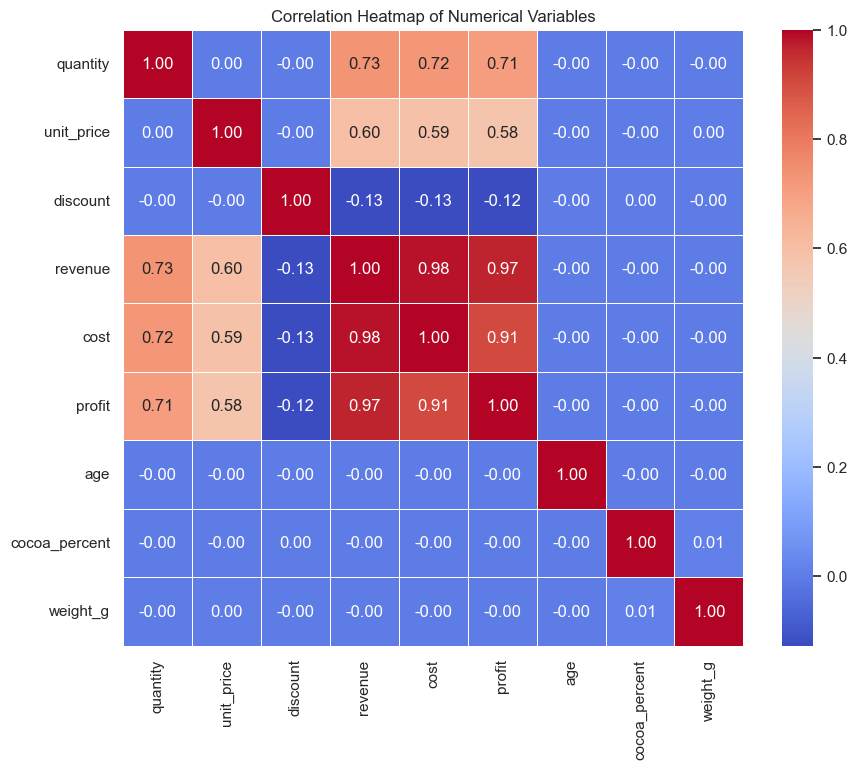

In [12]:
corr_matrix = df[['quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit', 'age', 'cocoa_percent', 'weight_g']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()
